# Dataset analysis

Full dataset EDA across the semantic game groups used for model evaluation:

- `professional`
- `public`
- `synthetic`

The analysis intentionally ignores the storage table as an evaluation concept. Dotabuff and OpenDota are ingestion sources; the questions here are about game type, hero frequency, hero win rate, and how each hero's appearances are split across game types.


In [37]:
import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import scripts.ml.dataset as dataset_module

importlib.reload(dataset_module)

DatasetMaker = dataset_module.DatasetMaker
HERO_ALIASES = dataset_module.HERO_ALIASES
HEROES_PATH = dataset_module.HEROES_PATH
normalize_hero_name = dataset_module.normalize_hero_name

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")


In [38]:
GROUP_ORDER = ["professional", "public", "synthetic"]
GROUP_COLORS = {
    "professional": "#2f6fbb",
    "public": "#3a9d73",
    "synthetic": "#b565c0",
}

TOP_N = 25
MIN_APPEARANCES = 25


In [39]:
DATASET_HERO_ROWS_QUERY = "\nWITH dotabuff_complete_matches AS (\n    SELECT\n        m.match_id\n    FROM dotabuff_matches m\n    JOIN dotabuff_match_players p ON p.match_id = m.match_id\n    WHERE\n        m.winner_side IN ('radiant', 'dire')\n        AND p.side IN ('radiant', 'dire')\n        AND p.hero_slug IS NOT NULL\n    GROUP BY m.match_id\n    HAVING\n        COUNT(*) = 10\n        AND COUNT(*) FILTER (WHERE p.side = 'radiant') = 5\n        AND COUNT(*) FILTER (WHERE p.side = 'dire') = 5\n),\nopendota_complete_matches AS (\n    SELECT\n        m.match_id\n    FROM opendota_matches m\n    WHERE\n        m.winner_side IN ('radiant', 'dire')\n        AND jsonb_array_length(coalesce(m.players->'radiant', '[]'::jsonb)) = 5\n        AND jsonb_array_length(coalesce(m.players->'dire', '[]'::jsonb)) = 5\n        AND NOT EXISTS (\n            SELECT 1\n            FROM jsonb_array_elements(\n                coalesce(m.players->'radiant', '[]'::jsonb) || coalesce(m.players->'dire', '[]'::jsonb)\n            ) AS players(player)\n            WHERE players.player->>'hero' IS NULL\n        )\n        AND NOT EXISTS (\n            SELECT 1\n            FROM dotabuff_matches dm\n            WHERE dm.match_id = m.match_id\n        )\n),\nreal_hero_rows AS (\n    SELECT\n        'dotabuff' AS ingestion_source,\n        CASE WHEN m.is_professional_match THEN 'professional' ELSE 'public' END AS game_group,\n        m.match_id::text AS source_match_id,\n        'dotabuff:' || m.match_id::text AS match_key,\n        m.winner_side,\n        p.side,\n        p.hero_slug AS hero\n    FROM dotabuff_complete_matches cm\n    JOIN dotabuff_matches m ON m.match_id = cm.match_id\n    JOIN dotabuff_match_players p ON p.match_id = cm.match_id\n    WHERE\n        p.side IN ('radiant', 'dire')\n        AND p.hero_slug IS NOT NULL\n\n    UNION ALL\n\n    SELECT\n        'opendota' AS ingestion_source,\n        CASE WHEN m.radiant_team_id IS NOT NULL THEN 'professional' ELSE 'public' END AS game_group,\n        m.match_id::text AS source_match_id,\n        'opendota:' || m.match_id::text AS match_key,\n        m.winner_side,\n        player_rows.side,\n        player_rows.hero\n    FROM opendota_complete_matches cm\n    JOIN opendota_matches m ON m.match_id = cm.match_id\n    CROSS JOIN LATERAL (\n        SELECT\n            'radiant' AS side,\n            player->>'hero' AS hero\n        FROM jsonb_array_elements(m.players->'radiant') AS players(player)\n        UNION ALL\n        SELECT\n            'dire' AS side,\n            player->>'hero' AS hero\n        FROM jsonb_array_elements(m.players->'dire') AS players(player)\n    ) player_rows\n),\nsynthetic_hero_rows AS (\n    SELECT\n        'synthetic' AS ingestion_source,\n        'synthetic' AS game_group,\n        s.synthetic_match_id::text AS source_match_id,\n        'synthetic:' || s.synthetic_match_id::text AS match_key,\n        s.winner_side,\n        'radiant' AS side,\n        hero AS hero\n    FROM synthetic_outdraft_matches s\n    CROSS JOIN LATERAL unnest(s.radiant_hero_slugs) AS hero\n\n    UNION ALL\n\n    SELECT\n        'synthetic' AS ingestion_source,\n        'synthetic' AS game_group,\n        s.synthetic_match_id::text AS source_match_id,\n        'synthetic:' || s.synthetic_match_id::text AS match_key,\n        s.winner_side,\n        'dire' AS side,\n        hero AS hero\n    FROM synthetic_outdraft_matches s\n    CROSS JOIN LATERAL unnest(s.dire_hero_slugs) AS hero\n)\nSELECT *\nFROM real_hero_rows\nUNION ALL\nSELECT *\nFROM synthetic_hero_rows\n"


In [40]:
def load_hero_name_by_key(path=HEROES_PATH):
    heroes = json.loads(Path(path).read_text(encoding="utf-8"))
    names = {}

    for hero in heroes.values():
        localized_name = hero.get("localized_name")
        internal_name = hero.get("name")
        if not localized_name:
            continue

        names[normalize_hero_name(localized_name)] = localized_name
        if internal_name:
            short_name = internal_name.removeprefix("npc_dota_hero_")
            names[normalize_hero_name(short_name)] = localized_name

    return names


hero_name_by_key = load_hero_name_by_key()


def canonical_hero_key(value):
    key = normalize_hero_name(value)
    return HERO_ALIASES.get(key, key)


def hero_display_name(canonical_key):
    return hero_name_by_key.get(canonical_key, canonical_key)


In [41]:
with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
    with dataset._conn.cursor() as cur:
        cur.execute(DATASET_HERO_ROWS_QUERY)
        hero_rows = pd.DataFrame(cur.fetchall())

hero_rows["game_group"] = pd.Categorical(hero_rows["game_group"], categories=GROUP_ORDER, ordered=True)
hero_rows["won"] = hero_rows["side"] == hero_rows["winner_side"]
hero_rows["hero_key"] = hero_rows["hero"].map(canonical_hero_key)
hero_rows["hero_name"] = hero_rows["hero_key"].map(hero_display_name)

hero_rows.head(), hero_rows.shape


(  ingestion_source    game_group source_match_id            match_key winner_side     side         hero    won    hero_key    hero_name
 0         dotabuff  professional      8670244221  dotabuff:8670244221        dire  radiant       medusa  False      medusa       Medusa
 1         dotabuff  professional      8670244221  dotabuff:8670244221        dire  radiant        largo  False       largo        Largo
 2         dotabuff  professional      8670244221  dotabuff:8670244221        dire  radiant         tiny  False        tiny         Tiny
 3         dotabuff  professional      8670244221  dotabuff:8670244221        dire  radiant  dark-willow  False  darkwillow  Dark Willow
 4         dotabuff  professional      8670244221  dotabuff:8670244221        dire  radiant   brewmaster  False  brewmaster   Brewmaster,
 (164580, 10))

## Dataset overview

In [42]:
match_rows = hero_rows.drop_duplicates(["game_group", "match_key"])

dataset_summary = pd.DataFrame(
    {
        "matches": match_rows.groupby("game_group", observed=False)["match_key"].nunique(),
        "hero_appearances": hero_rows.groupby("game_group", observed=False).size(),
        "unique_heroes": hero_rows.groupby("game_group", observed=False)["hero_key"].nunique(),
        "radiant_win_rate": match_rows.groupby("game_group", observed=False)["winner_side"].apply(lambda s: (s == "radiant").mean()),
    }
).reset_index()

dataset_summary["match_share"] = dataset_summary["matches"] / dataset_summary["matches"].sum()
dataset_summary


,game_group,matches,hero_appearances,unique_heroes,radiant_win_rate,match_share
0,professional,4901,49010,127,0.507651,0.297788
1,public,1557,15570,127,0.544637,0.094604
2,synthetic,10000,100000,97,0.500300,0.607607


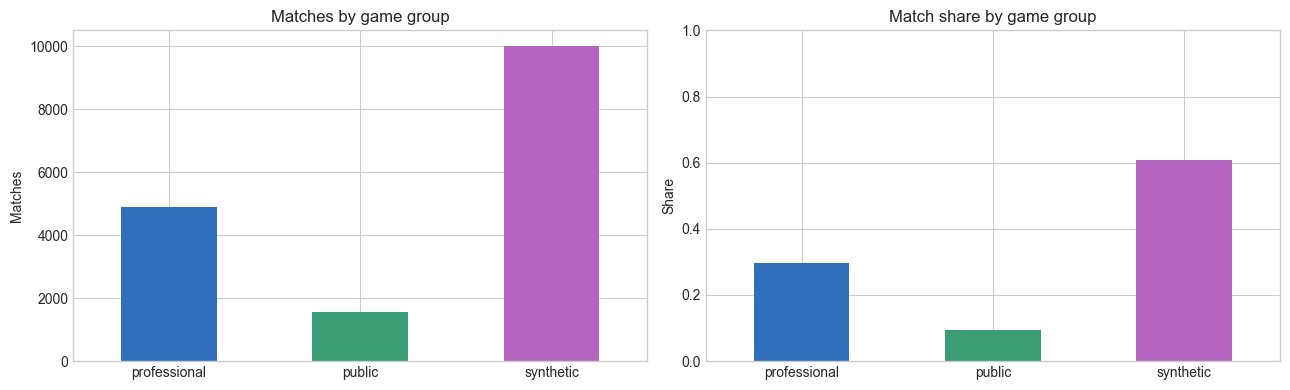

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

summary_for_plot = dataset_summary.set_index("game_group").loc[GROUP_ORDER]
summary_for_plot["matches"].plot.bar(
    ax=axes[0],
    color=[GROUP_COLORS[group] for group in summary_for_plot.index],
)
axes[0].set_title("Matches by game group")
axes[0].set_xlabel("")
axes[0].set_ylabel("Matches")
axes[0].tick_params(axis="x", rotation=0)

summary_for_plot["match_share"].plot.bar(
    ax=axes[1],
    color=[GROUP_COLORS[group] for group in summary_for_plot.index],
)
axes[1].set_title("Match share by game group")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()


## Hero stats overall and by game group

In [44]:
def aggregate_hero_stats(frame, group_cols):
    rows = []
    for keys, group in frame.groupby(group_cols, observed=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        side = group["side"]
        won = group["won"]
        appearances = len(group)
        radiant_picks = int((side == "radiant").sum())
        dire_picks = int((side == "dire").sum())
        radiant_wins = int(((side == "radiant") & won).sum())
        dire_wins = int(((side == "dire") & won).sum())
        row = dict(zip(group_cols, keys))
        row.update(
            appearances=appearances,
            wins=int(won.sum()),
            radiant_picks=radiant_picks,
            dire_picks=dire_picks,
            radiant_wins=radiant_wins,
            dire_wins=dire_wins,
        )
        rows.append(row)

    stats = pd.DataFrame(rows)
    stats["win_rate"] = stats["wins"] / stats["appearances"]
    stats["pick_share"] = stats["appearances"] / stats["appearances"].sum()
    stats["radiant_pick_share"] = stats["radiant_picks"] / stats["appearances"]
    stats["dire_pick_share"] = stats["dire_picks"] / stats["appearances"]
    stats["radiant_win_rate"] = stats["radiant_wins"] / stats["radiant_picks"].where(stats["radiant_picks"] > 0)
    stats["dire_win_rate"] = stats["dire_wins"] / stats["dire_picks"].where(stats["dire_picks"] > 0)
    return stats


overall_hero_stats = aggregate_hero_stats(hero_rows, ["hero_key", "hero_name"]).sort_values(
    ["appearances", "win_rate"], ascending=[False, False]
)

group_hero_stats = aggregate_hero_stats(hero_rows, ["game_group", "hero_key", "hero_name"])
group_totals = hero_rows.groupby("game_group", observed=False).size().rename("group_appearances").reset_index()
group_hero_stats = group_hero_stats.merge(group_totals, on="game_group")
group_hero_stats["group_pick_share"] = group_hero_stats["appearances"] / group_hero_stats["group_appearances"]

overall_hero_stats.head(20)


,hero_key,hero_name,appearances,wins,radiant_picks,dire_picks,radiant_wins,dire_wins,win_rate,pick_share,radiant_pick_share,dire_pick_share,radiant_win_rate,dire_win_rate
111,tusk,Tusk,3472,2056,1760,1712,1062,994,0.592166,0.021096,0.506912,0.493088,0.603409,0.580607
3,antimage,Anti-Mage,3263,1313,1648,1615,665,648,0.402390,0.019826,0.505057,0.494943,0.403519,0.401238
42,jakiro,Jakiro,3239,1988,1563,1676,968,1020,0.613770,0.019680,0.482556,0.517444,0.619322,0.608592
103,templarassassin,Templar Assassin,2827,750,1420,1407,366,384,0.265299,0.017177,0.502299,0.497701,0.257746,0.272921
18,clockwerk,Clockwerk,2680,1682,1337,1343,847,835,0.627612,0.016284,0.498881,0.501119,0.633508,0.621742
99,spiritbreaker,Spirit Breaker,2528,1600,1278,1250,824,776,0.632911,0.015360,0.505538,0.494462,0.644757,0.620800
0,abaddon,Abaddon,2493,695,1297,1196,373,322,0.278781,0.015148,0.520257,0.479743,0.287587,0.269231
12,bristleback,Bristleback,2443,1229,1226,1217,621,608,0.503070,0.014844,0.501842,0.498158,0.506525,0.499589
100,stormspirit,Storm Spirit,2395,1278,1207,1188,670,608,0.533612,0.014552,0.503967,0.496033,0.555095,0.511785
51,lifestealer,Lifestealer,2393,1481,1181,1212,725,756,0.618888,0.014540,0.493523,0.506477,0.613887,0.623762


In [45]:
group_hero_stats.sort_values(["game_group", "appearances"], ascending=[True, False]).groupby(
    "game_group", observed=False
).head(10)


,game_group,hero_key,hero_name,appearances,wins,radiant_picks,dire_picks,radiant_wins,dire_wins,win_rate,pick_share,radiant_pick_share,dire_pick_share,radiant_win_rate,dire_win_rate,group_appearances,group_pick_share
42,professional,jakiro,Jakiro,1201,576,585,616,295,281,0.479600,0.007297,0.487094,0.512906,0.504274,0.456169,49010,0.024505
111,professional,tusk,Tusk,1187,565,620,567,306,259,0.475990,0.007212,0.522325,0.477675,0.493548,0.456790,49010,0.024220
108,professional,tiny,Tiny,1098,547,552,546,283,264,0.498179,0.006672,0.502732,0.497268,0.512681,0.483516,49010,0.022404
38,professional,hoodwink,Hoodwink,1005,515,495,510,258,257,0.512438,0.006106,0.492537,0.507463,0.521212,0.503922,49010,0.020506
75,professional,pangolier,Pangolier,992,460,464,528,236,224,0.463710,0.006027,0.467742,0.532258,0.508621,0.424242,49010,0.020241
80,professional,puck,Puck,992,467,490,502,228,239,0.470766,0.006027,0.493952,0.506048,0.465306,0.476096,49010,0.020241
100,professional,stormspirit,Storm Spirit,958,448,465,493,228,220,0.467641,0.005821,0.485386,0.514614,0.490323,0.446247,49010,0.019547
32,professional,emberspirit,Ember Spirit,942,496,476,466,246,250,0.526539,0.005724,0.505308,0.494692,0.516807,0.536481,49010,0.019221
8,professional,beastmaster,Beastmaster,883,428,480,403,241,187,0.484711,0.005365,0.543601,0.456399,0.502083,0.464020,49010,0.018017
120,professional,warlock,Warlock,838,406,412,426,197,209,0.484487,0.005092,0.491647,0.508353,0.478155,0.490610,49010,0.017099


## Real-only hero stats

These blocks exclude synthetic games. Use them when you want the real data shape without the synthetic generator dominating appearance counts or win rates.


In [46]:
real_hero_rows = hero_rows[hero_rows["game_group"].isin(["professional", "public"])].copy()

real_hero_stats = aggregate_hero_stats(real_hero_rows, ["hero_key", "hero_name"]).sort_values(
    ["appearances", "win_rate"], ascending=[False, False]
)

real_group_hero_stats = aggregate_hero_stats(real_hero_rows, ["game_group", "hero_key", "hero_name"])
real_group_totals = real_hero_rows.groupby("game_group", observed=False).size().rename("group_appearances").reset_index()
real_group_hero_stats = real_group_hero_stats.merge(real_group_totals, on="game_group")
real_group_hero_stats["group_pick_share"] = real_group_hero_stats["appearances"] / real_group_hero_stats["group_appearances"]

real_hero_stats.head(20)


,hero_key,hero_name,appearances,wins,radiant_picks,dire_picks,radiant_wins,dire_wins,win_rate,pick_share,radiant_pick_share,dire_pick_share,radiant_win_rate,dire_win_rate
42,jakiro,Jakiro,1376,666,665,711,333,333,0.484012,0.021307,0.483285,0.516715,0.500752,0.468354
111,tusk,Tusk,1326,631,686,640,340,291,0.475867,0.020533,0.517345,0.482655,0.495627,0.454688
108,tiny,Tiny,1257,627,628,629,329,298,0.498807,0.019464,0.499602,0.500398,0.523885,0.473768
38,hoodwink,Hoodwink,1209,626,601,608,320,306,0.517783,0.018721,0.497105,0.502895,0.532446,0.503289
75,pangolier,Pangolier,1110,520,519,591,271,249,0.468468,0.017188,0.467568,0.532432,0.522158,0.421320
32,emberspirit,Ember Spirit,1059,545,539,520,272,273,0.514636,0.016398,0.508971,0.491029,0.504638,0.525000
100,stormspirit,Storm Spirit,1049,493,511,538,248,245,0.469971,0.016243,0.487131,0.512869,0.485323,0.455390
80,puck,Puck,1044,487,514,530,234,253,0.466475,0.016166,0.492337,0.507663,0.455253,0.477358
8,beastmaster,Beastmaster,989,467,538,451,261,206,0.472194,0.015314,0.543984,0.456016,0.485130,0.456763
91,shadowshaman,Shadow Shaman,974,516,503,471,267,249,0.529774,0.015082,0.516427,0.483573,0.530815,0.528662


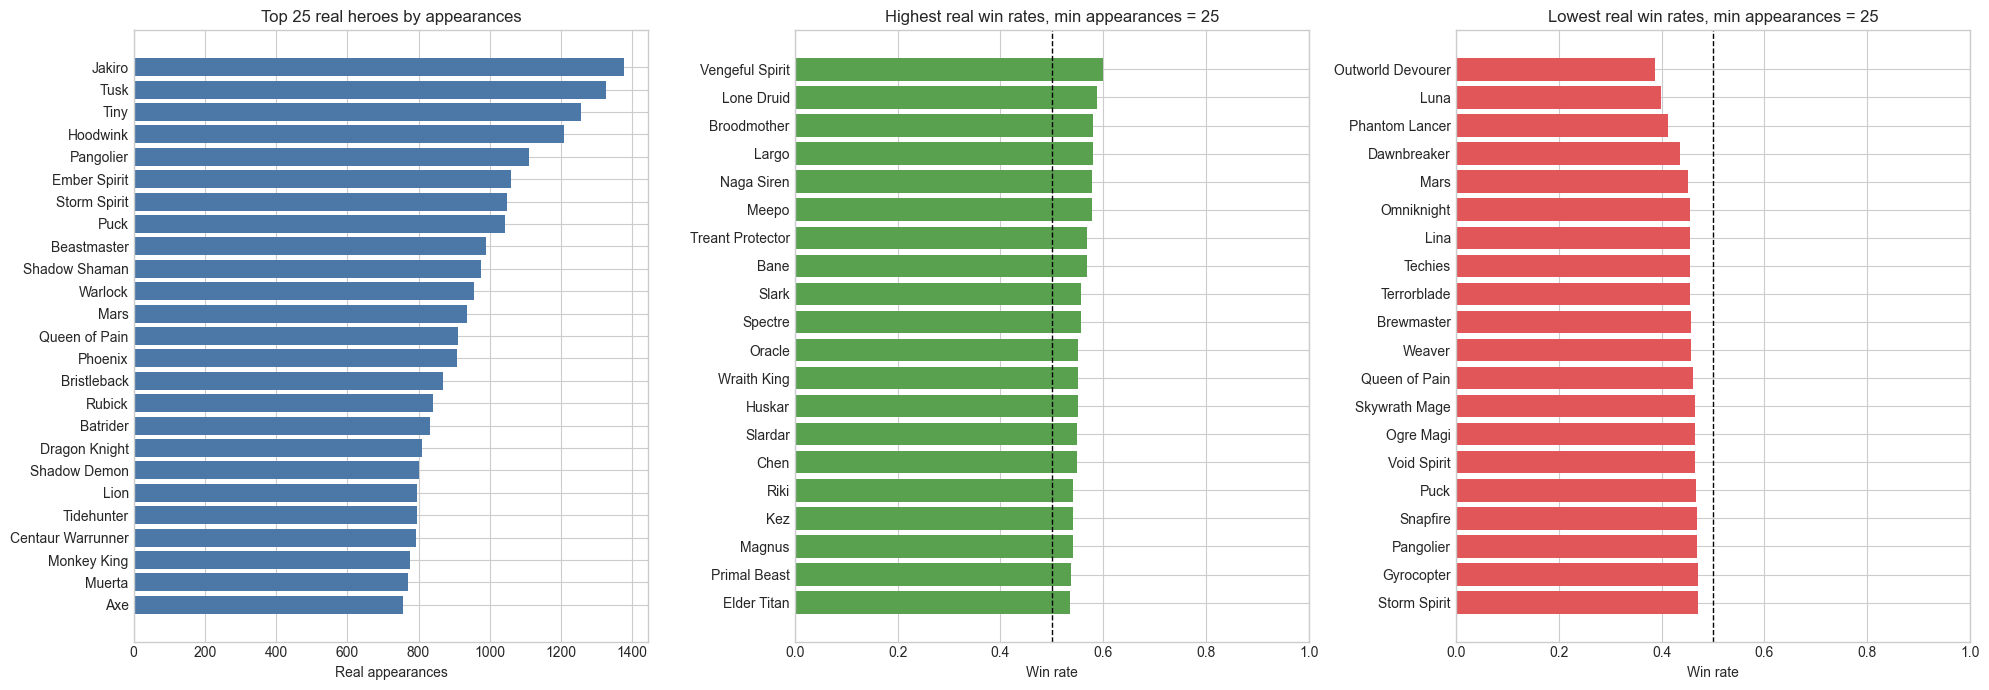

In [47]:
real_popular = real_hero_stats[real_hero_stats["appearances"] >= MIN_APPEARANCES]
real_top_picked = real_hero_stats.head(TOP_N).sort_values("appearances")
real_highest_wr = real_popular.sort_values("win_rate", ascending=False).head(20).sort_values("win_rate")
real_lowest_wr = real_popular.sort_values("win_rate", ascending=True).head(20).sort_values("win_rate", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].barh(real_top_picked["hero_name"], real_top_picked["appearances"], color="#4c78a8")
axes[0].set_title(f"Top {TOP_N} real heroes by appearances")
axes[0].set_xlabel("Real appearances")
axes[0].set_ylabel("")

axes[1].barh(real_highest_wr["hero_name"], real_highest_wr["win_rate"], color="#59a14f")
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"Highest real win rates, min appearances = {MIN_APPEARANCES}")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Win rate")

axes[2].barh(real_lowest_wr["hero_name"], real_lowest_wr["win_rate"], color="#e15759")
axes[2].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[2].set_title(f"Lowest real win rates, min appearances = {MIN_APPEARANCES}")
axes[2].set_xlim(0, 1)
axes[2].set_xlabel("Win rate")

plt.tight_layout()


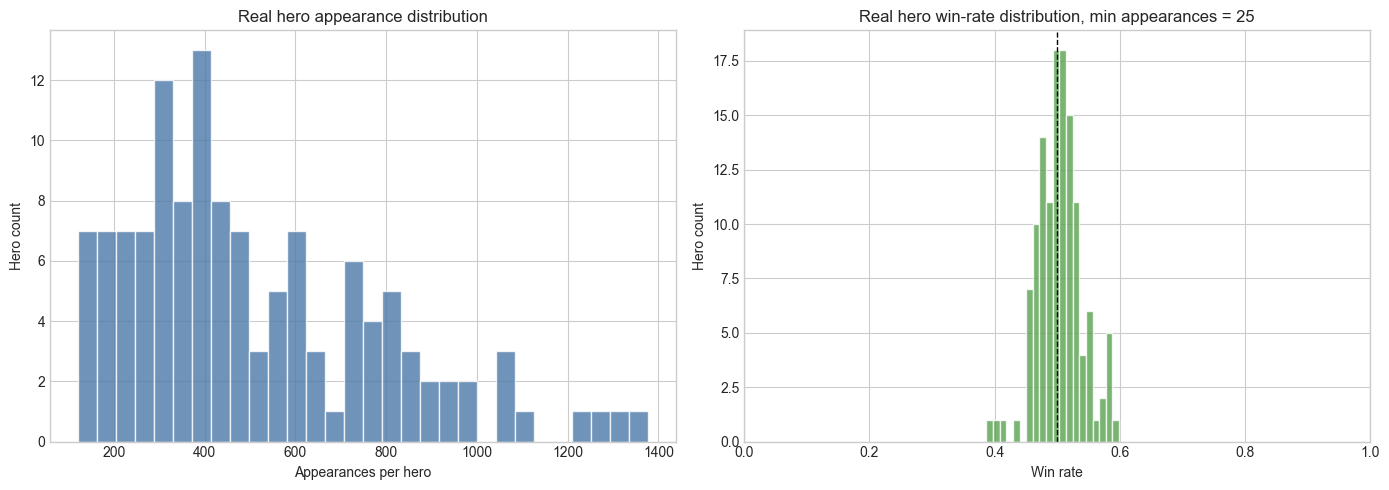

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(real_hero_stats["appearances"], bins=30, color="#4c78a8", alpha=0.8, edgecolor="white")
axes[0].set_title("Real hero appearance distribution")
axes[0].set_xlabel("Appearances per hero")
axes[0].set_ylabel("Hero count")

axes[1].hist(real_popular["win_rate"], bins=20, color="#59a14f", alpha=0.8, edgecolor="white")
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"Real hero win-rate distribution, min appearances = {MIN_APPEARANCES}")
axes[1].set_xlabel("Win rate")
axes[1].set_ylabel("Hero count")
axes[1].set_xlim(0, 1)

plt.tight_layout()


## Hero appearance frequency

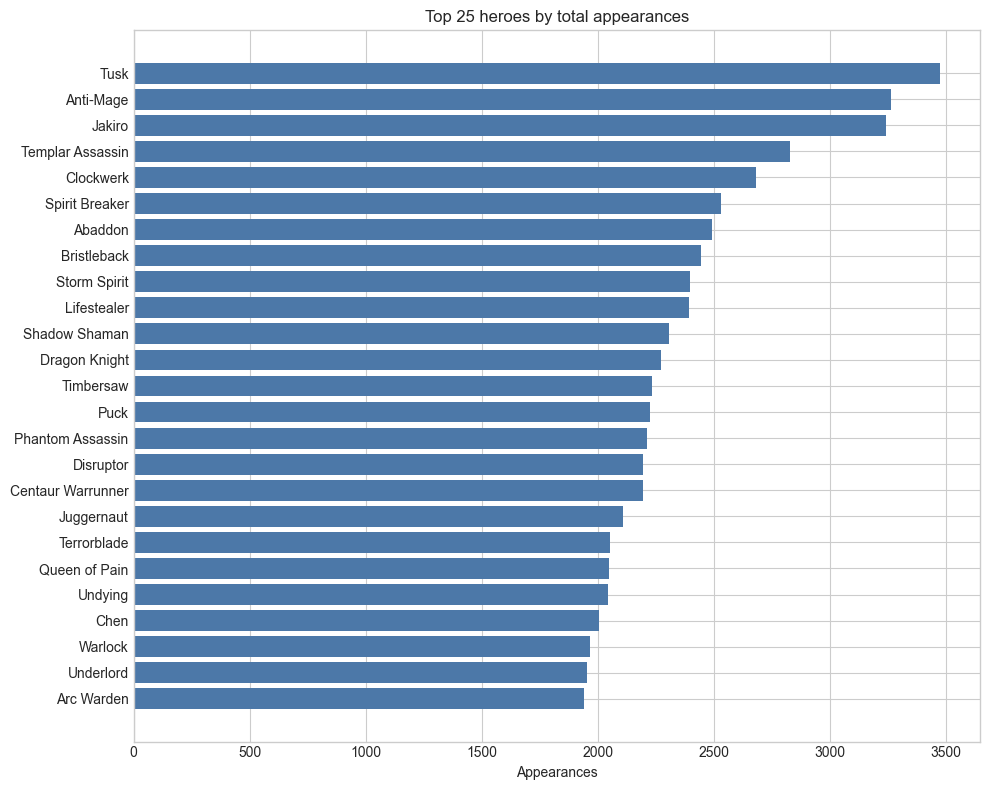

In [49]:
top_overall = overall_hero_stats.head(TOP_N).sort_values("appearances")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_overall["hero_name"], top_overall["appearances"], color="#4c78a8")
ax.set_title(f"Top {TOP_N} heroes by total appearances")
ax.set_xlabel("Appearances")
ax.set_ylabel("")
plt.tight_layout()


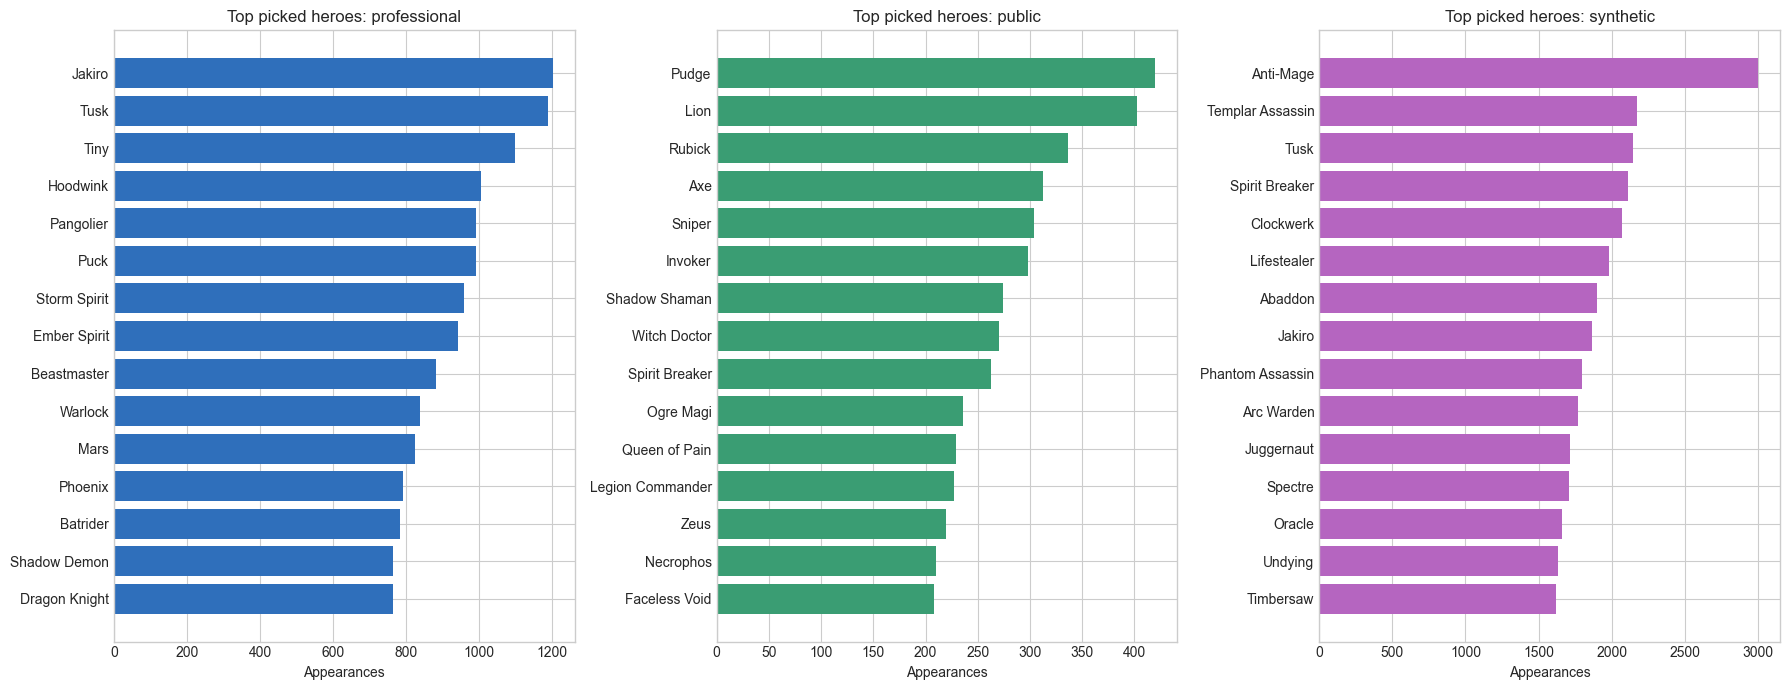

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=False)

for ax, group in zip(axes, GROUP_ORDER):
    subset = group_hero_stats[group_hero_stats["game_group"] == group].sort_values("appearances", ascending=False).head(15)
    subset = subset.sort_values("appearances")
    ax.barh(subset["hero_name"], subset["appearances"], color=GROUP_COLORS[group])
    ax.set_title(f"Top picked heroes: {group}")
    ax.set_xlabel("Appearances")
    ax.set_ylabel("")

plt.tight_layout()


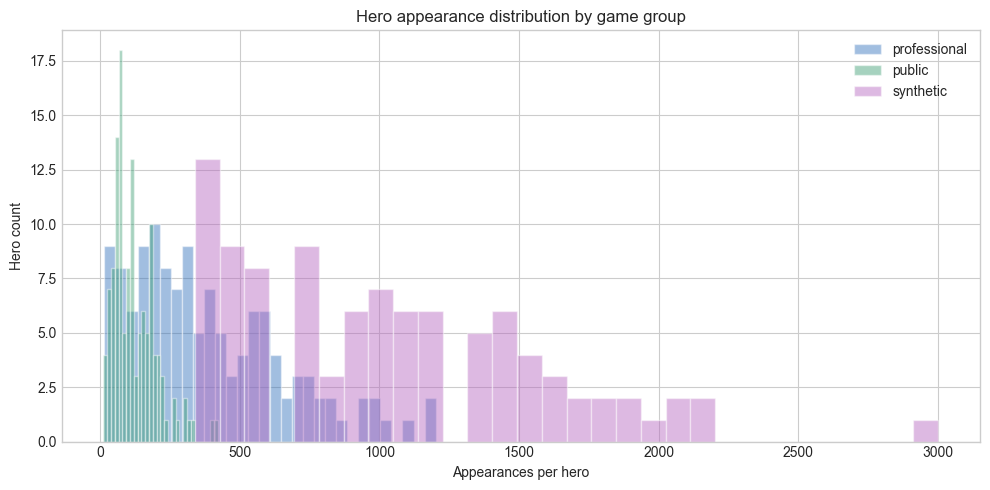

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))
for group in GROUP_ORDER:
    values = group_hero_stats[group_hero_stats["game_group"] == group]["appearances"]
    ax.hist(values, bins=30, alpha=0.45, label=group, color=GROUP_COLORS[group], edgecolor="white")

ax.set_title("Hero appearance distribution by game group")
ax.set_xlabel("Appearances per hero")
ax.set_ylabel("Hero count")
ax.legend()
plt.tight_layout()


## Hero win rates

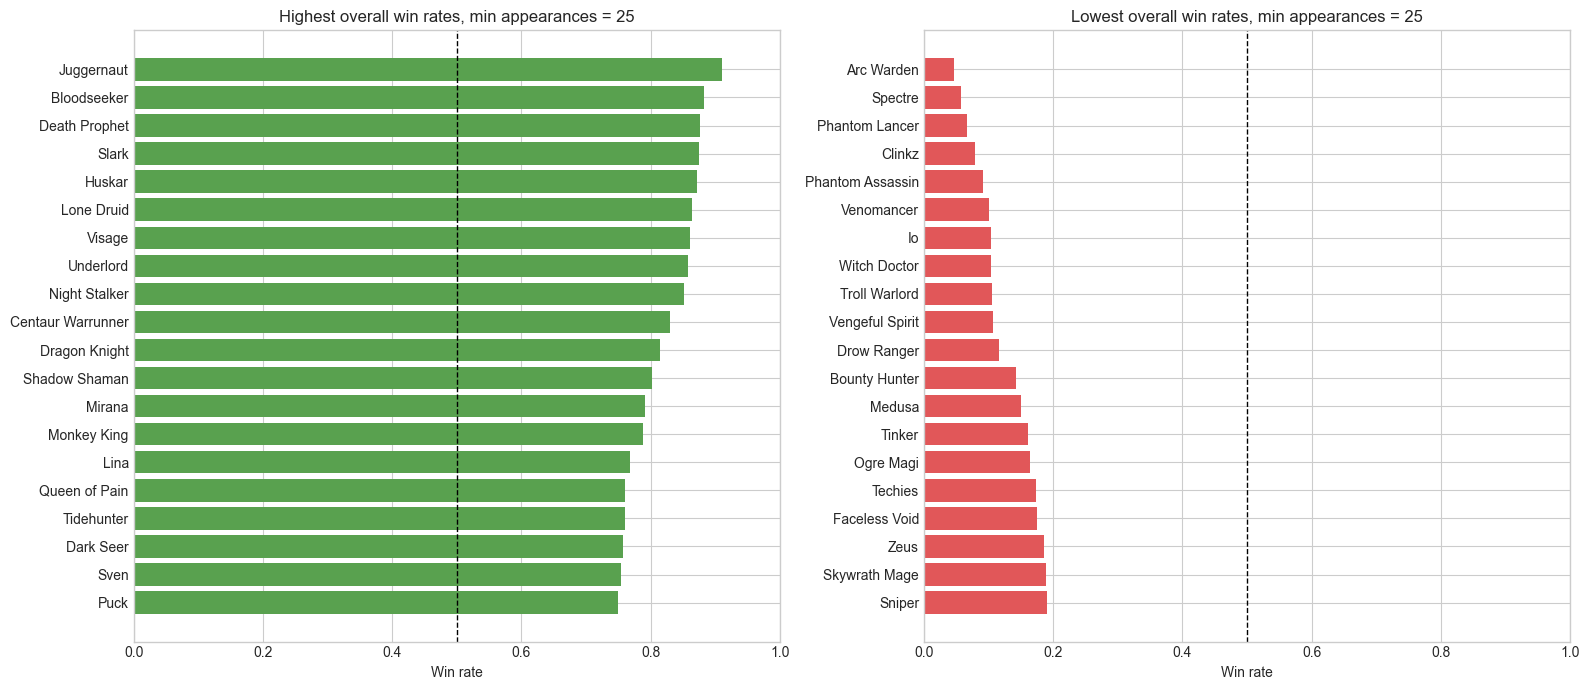

In [52]:
popular_overall = overall_hero_stats[overall_hero_stats["appearances"] >= MIN_APPEARANCES]

highest_wr = popular_overall.sort_values("win_rate", ascending=False).head(20).sort_values("win_rate")
lowest_wr = popular_overall.sort_values("win_rate", ascending=True).head(20).sort_values("win_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(highest_wr["hero_name"], highest_wr["win_rate"], color="#59a14f")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set_title(f"Highest overall win rates, min appearances = {MIN_APPEARANCES}")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Win rate")

axes[1].barh(lowest_wr["hero_name"], lowest_wr["win_rate"], color="#e15759")
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"Lowest overall win rates, min appearances = {MIN_APPEARANCES}")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Win rate")

plt.tight_layout()


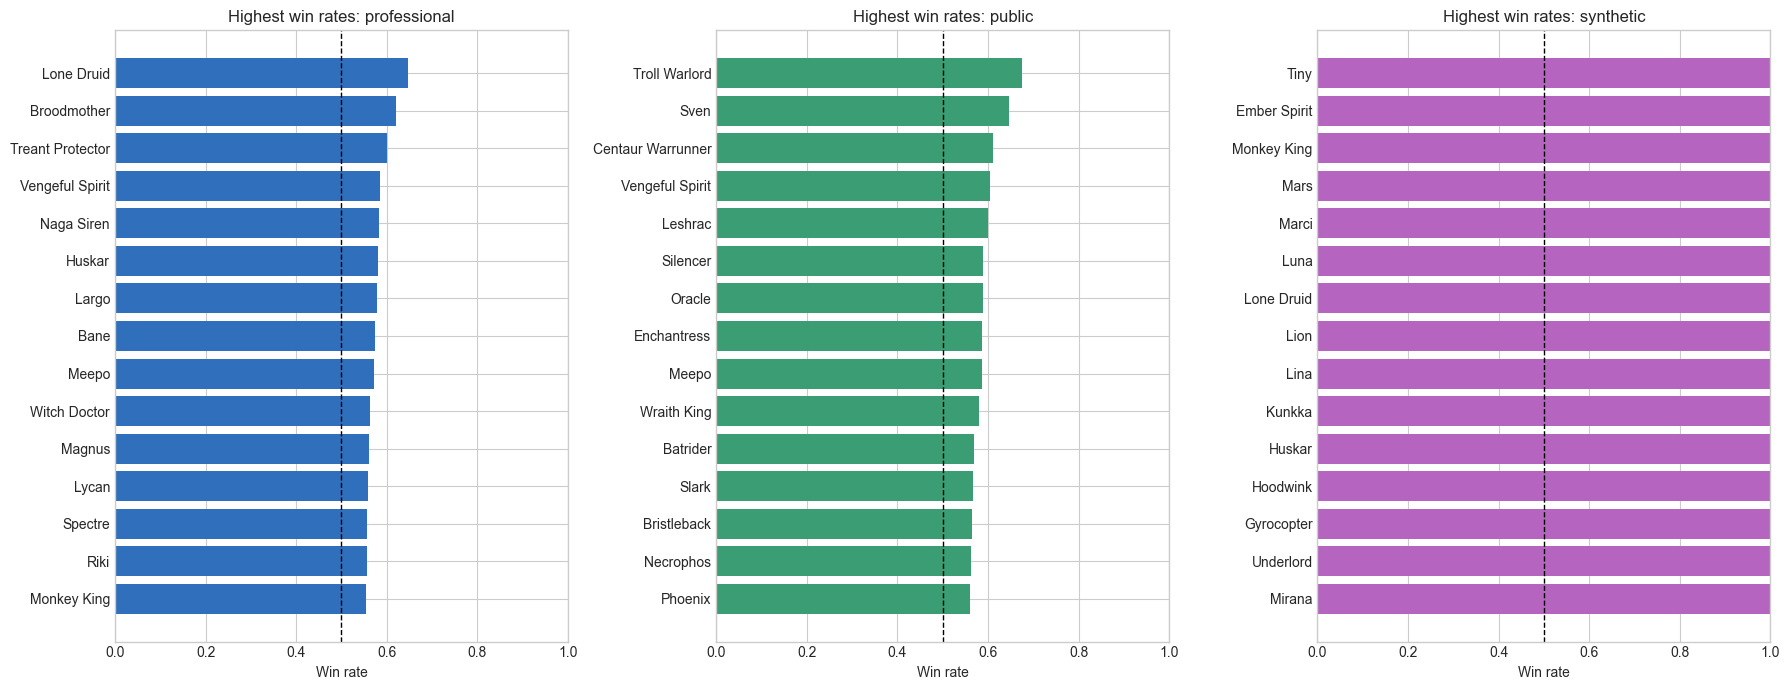

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True)

for ax, group in zip(axes, GROUP_ORDER):
    subset = group_hero_stats[
        (group_hero_stats["game_group"] == group)
        & (group_hero_stats["appearances"] >= MIN_APPEARANCES)
    ].sort_values("win_rate", ascending=False).head(15)
    subset = subset.sort_values("win_rate")
    ax.barh(subset["hero_name"], subset["win_rate"], color=GROUP_COLORS[group])
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Highest win rates: {group}")
    ax.set_xlabel("Win rate")
    ax.set_xlim(0, 1)
    ax.set_ylabel("")

plt.tight_layout()


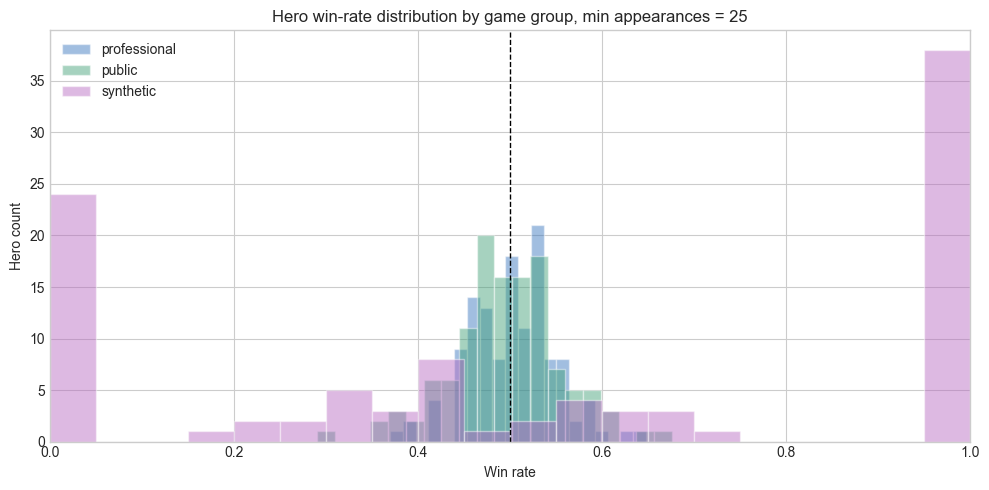

In [54]:
fig, ax = plt.subplots(figsize=(10, 5))
for group in GROUP_ORDER:
    subset = group_hero_stats[
        (group_hero_stats["game_group"] == group)
        & (group_hero_stats["appearances"] >= MIN_APPEARANCES)
    ]
    ax.hist(subset["win_rate"], bins=20, alpha=0.45, label=group, color=GROUP_COLORS[group], edgecolor="white")

ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title(f"Hero win-rate distribution by game group, min appearances = {MIN_APPEARANCES}")
ax.set_xlabel("Win rate")
ax.set_ylabel("Hero count")
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()


## Hero game-type mix

For every hero, this section answers: what fraction of that hero's appearances came from professional, public, and synthetic games?


In [55]:
hero_group_mix = (
    group_hero_stats.pivot_table(
        index=["hero_key", "hero_name"],
        columns="game_group",
        values="appearances",
        fill_value=0,
        observed=False,
    )
    .reset_index()
)

for group in GROUP_ORDER:
    if group not in hero_group_mix.columns:
        hero_group_mix[group] = 0

hero_group_mix["total_appearances"] = hero_group_mix[GROUP_ORDER].sum(axis=1)
for group in GROUP_ORDER:
    hero_group_mix[f"{group}_share"] = hero_group_mix[group] / hero_group_mix["total_appearances"].where(
        hero_group_mix["total_appearances"] > 0
    )

hero_group_mix = hero_group_mix.sort_values("total_appearances", ascending=False)
hero_group_mix.head(20)


game_group,hero_key,hero_name,professional,public,synthetic,total_appearances,professional_share,public_share,synthetic_share
111,tusk,Tusk,1187,139,2146,3472,0.341878,0.040035,0.618088
3,antimage,Anti-Mage,72,190,3001,3263,0.022066,0.058229,0.919706
42,jakiro,Jakiro,1201,175,1863,3239,0.370793,0.054029,0.575178
103,templarassassin,Templar Assassin,578,74,2175,2827,0.204457,0.026176,0.769367
18,clockwerk,Clockwerk,558,49,2073,2680,0.208209,0.018284,0.773507
99,spiritbreaker,Spirit Breaker,153,263,2112,2528,0.060522,0.104035,0.835443
0,abaddon,Abaddon,524,67,1902,2493,0.210189,0.026875,0.762936
12,bristleback,Bristleback,700,168,1575,2443,0.286533,0.068768,0.644699
100,stormspirit,Storm Spirit,958,91,1346,2395,0.400000,0.037996,0.562004
51,lifestealer,Lifestealer,247,164,1982,2393,0.103218,0.068533,0.828249


### Synthetic vs real and professional vs public appearances

Each point is a hero. These diagrams highlight where the synthetic generator over- or under-represents heroes relative to real data, and how professional/public real coverage differs.


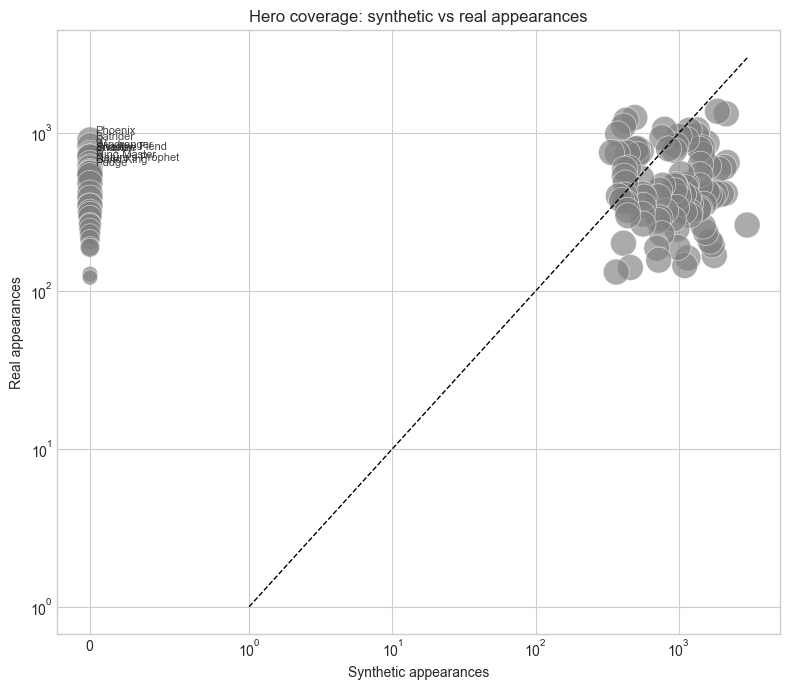

In [56]:
def annotate_top_offsets(ax, frame, x_col, y_col, label_col="hero_name", top_n=10):
    plot_frame = frame.copy()
    plot_frame["offset_score"] = (np.log1p(plot_frame[y_col]) - np.log1p(plot_frame[x_col])).abs()
    for _, row in plot_frame.nlargest(top_n, "offset_score").iterrows():
        ax.annotate(
            row[label_col],
            (row[x_col], row[y_col]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
            alpha=0.85,
        )


fig, ax = plt.subplots(figsize=(8, 7))
plot_frame = hero_group_mix.copy()
ax.scatter(
    plot_frame["synthetic"],
    plot_frame["professional"] + plot_frame["public"],
    s=np.clip(plot_frame["total_appearances"], 20, 350),
    alpha=0.65,
    color="#7f7f7f",
    edgecolors="white",
    linewidths=0.5,
)
max_value = max(plot_frame["synthetic"].max(), (plot_frame["professional"] + plot_frame["public"]).max())
ax.plot([1, max_value], [1, max_value], color="black", linestyle="--", linewidth=1)
ax.set_xscale("symlog", linthresh=1)
ax.set_yscale("symlog", linthresh=1)
ax.set_xlabel("Synthetic appearances")
ax.set_ylabel("Real appearances")
ax.set_title("Hero coverage: synthetic vs real appearances")
annotate_top_offsets(
    ax,
    plot_frame.assign(real_appearances=plot_frame["professional"] + plot_frame["public"]),
    "synthetic",
    "real_appearances",
)
plt.tight_layout()


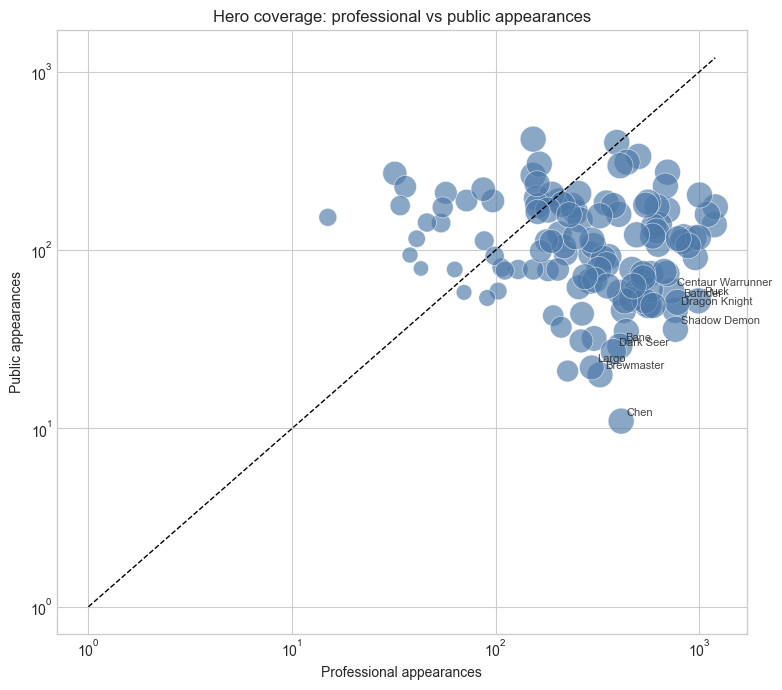

In [57]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_frame = hero_group_mix.copy()
ax.scatter(
    plot_frame["professional"],
    plot_frame["public"],
    s=np.clip(plot_frame["professional"] + plot_frame["public"], 20, 350),
    alpha=0.65,
    color="#4c78a8",
    edgecolors="white",
    linewidths=0.5,
)
max_value = max(plot_frame["professional"].max(), plot_frame["public"].max())
ax.plot([1, max_value], [1, max_value], color="black", linestyle="--", linewidth=1)
ax.set_xscale("symlog", linthresh=1)
ax.set_yscale("symlog", linthresh=1)
ax.set_xlabel("Professional appearances")
ax.set_ylabel("Public appearances")
ax.set_title("Hero coverage: professional vs public appearances")
annotate_top_offsets(ax, plot_frame, "professional", "public")
plt.tight_layout()


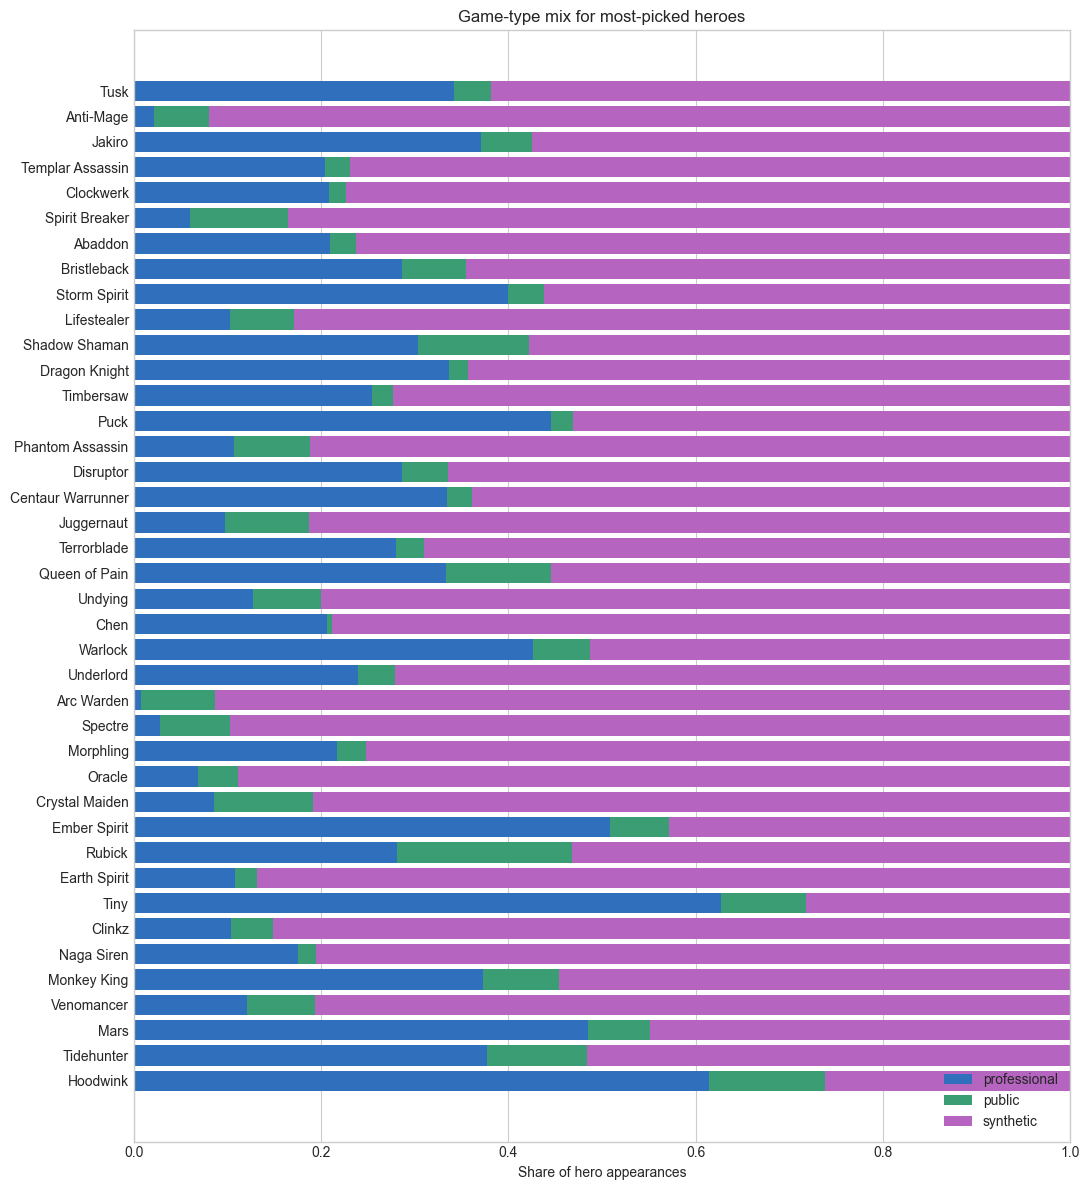

In [58]:
top_mix = hero_group_mix.head(40).sort_values("total_appearances")

fig, ax = plt.subplots(figsize=(11, 12))
left = np.zeros(len(top_mix))
y = np.arange(len(top_mix))

for group in GROUP_ORDER:
    values = top_mix[f"{group}_share"].to_numpy()
    ax.barh(y, values, left=left, label=group, color=GROUP_COLORS[group])
    left += values

ax.set_yticks(y)
ax.set_yticklabels(top_mix["hero_name"])
ax.set_xlim(0, 1)
ax.set_xlabel("Share of hero appearances")
ax.set_title("Game-type mix for most-picked heroes")
ax.legend(loc="lower right")
plt.tight_layout()


In [59]:
extreme_mix = pd.concat(
    [
        hero_group_mix.nlargest(10, f"{group}_share")[["hero_name", "total_appearances", group, f"{group}_share"]].assign(
            game_group=group
        )
        for group in GROUP_ORDER
    ],
    ignore_index=True,
)
extreme_mix


game_group,hero_name,total_appearances,professional,professional_share,game_group,public,public_share,synthetic,synthetic_share
0,Brewmaster,346,326.0,0.942197,professional,NaN,NaN,NaN,NaN
1,Batrider,833,782.0,0.938776,professional,NaN,NaN,NaN,NaN
2,Largo,319,297.0,0.931034,professional,NaN,NaN,NaN,NaN
3,Ring Master,643,594.0,0.923795,professional,NaN,NaN,NaN,NaN
4,Elder Titan,247,226.0,0.914980,professional,NaN,NaN,NaN,NaN
5,Lycan,294,263.0,0.894558,professional,NaN,NaN,NaN,NaN
6,Sand King,601,531.0,0.883527,professional,NaN,NaN,NaN,NaN
7,Primal Beast,538,475.0,0.882900,professional,NaN,NaN,NaN,NaN
8,Phoenix,907,791.0,0.872106,professional,NaN,NaN,NaN,NaN
9,Treant Protector,310,266.0,0.858065,professional,NaN,NaN,NaN,NaN


## Win rate vs frequency

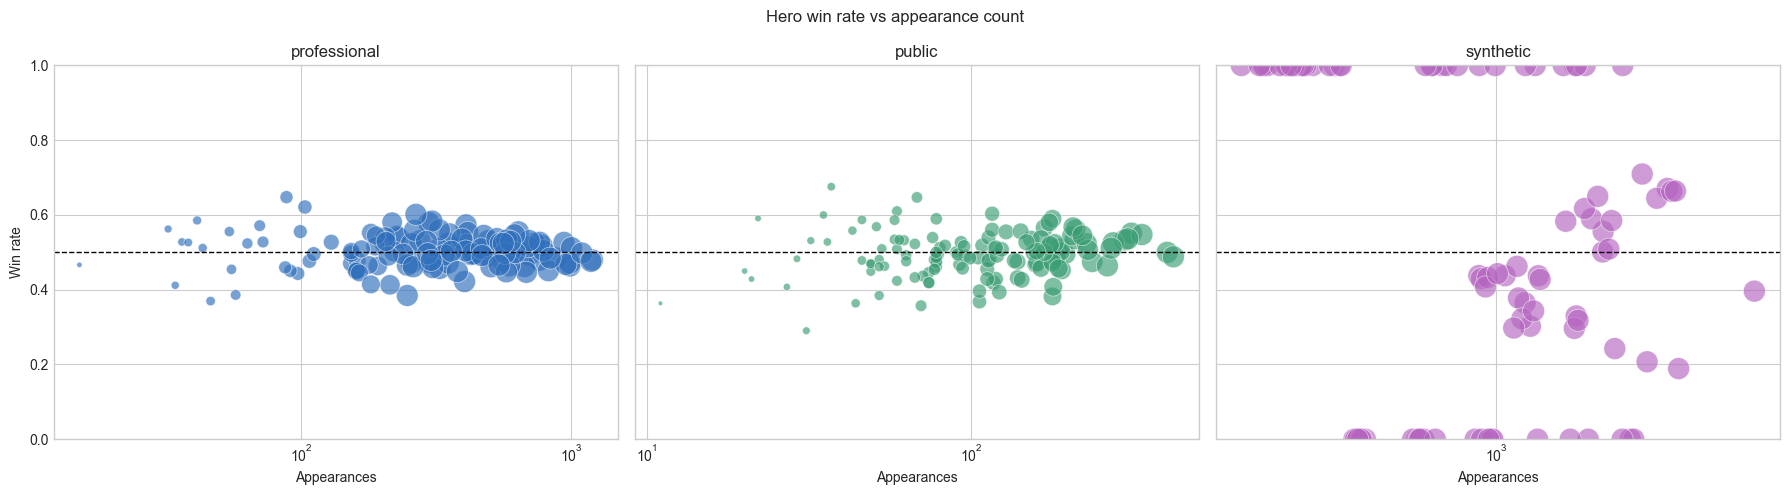

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, group in zip(axes, GROUP_ORDER):
    subset = group_hero_stats[group_hero_stats["game_group"] == group]
    ax.scatter(
        subset["appearances"],
        subset["win_rate"],
        s=np.clip(subset["appearances"], 10, 250),
        alpha=0.65,
        color=GROUP_COLORS[group],
        edgecolors="white",
        linewidths=0.5,
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(group)
    ax.set_xlabel("Appearances")
    ax.set_xscale("log")
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Win rate")
plt.suptitle("Hero win rate vs appearance count")
plt.tight_layout()


In [61]:
comparison = (
    group_hero_stats.pivot_table(
        index=["hero_key", "hero_name"],
        columns="game_group",
        values=["appearances", "win_rate"],
        observed=False,
    )
    .reset_index()
)
comparison.columns = ["_".join([str(part) for part in col if part]) for col in comparison.columns]
comparison = comparison.rename(columns={"hero_key": "hero_key", "hero_name": "hero_name"})

for group in GROUP_ORDER:
    comparison[f"appearances_{group}"] = comparison.get(f"appearances_{group}", 0).fillna(0)
    comparison[f"win_rate_{group}"] = comparison.get(f"win_rate_{group}", np.nan)

comparison["professional_minus_public_wr"] = comparison["win_rate_professional"] - comparison["win_rate_public"]
real_appearances = comparison["appearances_professional"].fillna(0) + comparison["appearances_public"].fillna(0)
real_wins_weighted = (
    comparison["win_rate_professional"].fillna(0) * comparison["appearances_professional"].fillna(0)
    + comparison["win_rate_public"].fillna(0) * comparison["appearances_public"].fillna(0)
)
comparison["real_win_rate"] = real_wins_weighted / real_appearances.replace(0, np.nan)
comparison["synthetic_minus_real_wr"] = comparison["win_rate_synthetic"] - comparison["real_win_rate"]

comparison.sort_values("professional_minus_public_wr", ascending=False).head(20)


,hero_key,hero_name,appearances_professional,appearances_public,appearances_synthetic,win_rate_professional,win_rate_public,win_rate_synthetic,professional_minus_public_wr,real_win_rate,synthetic_minus_real_wr
56,lycan,Lycan,263.0,31.0,0.0,0.558935,0.290323,NaN,0.268613,0.530612,NaN
109,treantprotector,Treant Protector,266.0,44.0,0.0,0.601504,0.363636,NaN,0.237867,0.567742,NaN
16,chen,Chen,414.0,11.0,1578.0,0.553140,0.363636,0.555767,0.189504,0.548235,0.007531
88,sandking,Sand King,531.0,70.0,0.0,0.536723,0.357143,NaN,0.179580,0.515807,NaN
67,naturesprophet,Nature's Prophet,493.0,122.0,0.0,0.531440,0.393443,NaN,0.137998,0.504065,NaN
63,monkeyking,Monkey King,638.0,139.0,932.0,0.554859,0.431655,1.000000,0.123204,0.532819,0.467181
90,shadowfiend,Shadow Fiend,547.0,179.0,0.0,0.524680,0.407821,NaN,0.116859,0.495868,NaN
8,beastmaster,Beastmaster,883.0,106.0,374.0,0.484711,0.367925,1.000000,0.116787,0.472194,0.527806
31,eldertitan,Elder Titan,226.0,21.0,0.0,0.544248,0.428571,NaN,0.115676,0.534413,NaN
103,templarassassin,Templar Assassin,578.0,74.0,2175.0,0.532872,0.418919,0.188966,0.113953,0.519939,-0.330973


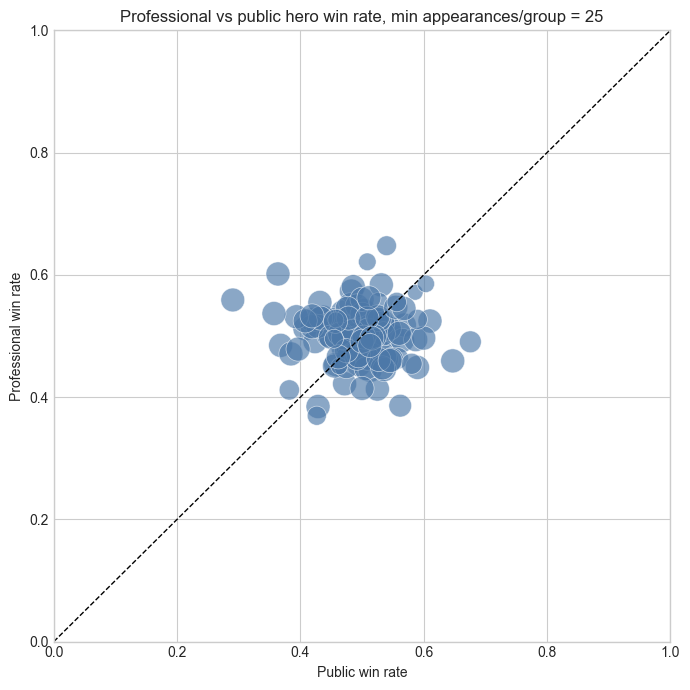

In [62]:
eligible = comparison[
    (comparison["appearances_professional"] >= MIN_APPEARANCES)
    & (comparison["appearances_public"] >= MIN_APPEARANCES)
].copy()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    eligible["win_rate_public"],
    eligible["win_rate_professional"],
    s=np.clip(eligible["appearances_professional"] + eligible["appearances_public"], 20, 300),
    alpha=0.65,
    color="#4c78a8",
    edgecolors="white",
    linewidths=0.5,
)
ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Public win rate")
ax.set_ylabel("Professional win rate")
ax.set_title(f"Professional vs public hero win rate, min appearances/group = {MIN_APPEARANCES}")
plt.tight_layout()


## Tables for inspection

In [63]:
overall_hero_stats.sort_values("appearances", ascending=False).head(30)


,hero_key,hero_name,appearances,wins,radiant_picks,dire_picks,radiant_wins,dire_wins,win_rate,pick_share,radiant_pick_share,dire_pick_share,radiant_win_rate,dire_win_rate
111,tusk,Tusk,3472,2056,1760,1712,1062,994,0.592166,0.021096,0.506912,0.493088,0.603409,0.580607
3,antimage,Anti-Mage,3263,1313,1648,1615,665,648,0.402390,0.019826,0.505057,0.494943,0.403519,0.401238
42,jakiro,Jakiro,3239,1988,1563,1676,968,1020,0.613770,0.019680,0.482556,0.517444,0.619322,0.608592
103,templarassassin,Templar Assassin,2827,750,1420,1407,366,384,0.265299,0.017177,0.502299,0.497701,0.257746,0.272921
18,clockwerk,Clockwerk,2680,1682,1337,1343,847,835,0.627612,0.016284,0.498881,0.501119,0.633508,0.621742
99,spiritbreaker,Spirit Breaker,2528,1600,1278,1250,824,776,0.632911,0.015360,0.505538,0.494462,0.644757,0.620800
0,abaddon,Abaddon,2493,695,1297,1196,373,322,0.278781,0.015148,0.520257,0.479743,0.287587,0.269231
12,bristleback,Bristleback,2443,1229,1226,1217,621,608,0.503070,0.014844,0.501842,0.498158,0.506525,0.499589
100,stormspirit,Storm Spirit,2395,1278,1207,1188,670,608,0.533612,0.014552,0.503967,0.496033,0.555095,0.511785
51,lifestealer,Lifestealer,2393,1481,1181,1212,725,756,0.618888,0.014540,0.493523,0.506477,0.613887,0.623762


In [64]:
group_hero_stats.sort_values(["game_group", "appearances"], ascending=[True, False]).groupby(
    "game_group", observed=False
).head(20)


,game_group,hero_key,hero_name,appearances,wins,radiant_picks,dire_picks,radiant_wins,dire_wins,win_rate,pick_share,radiant_pick_share,dire_pick_share,radiant_win_rate,dire_win_rate,group_appearances,group_pick_share
42,professional,jakiro,Jakiro,1201,576,585,616,295,281,0.479600,0.007297,0.487094,0.512906,0.504274,0.456169,49010,0.024505
111,professional,tusk,Tusk,1187,565,620,567,306,259,0.475990,0.007212,0.522325,0.477675,0.493548,0.456790,49010,0.024220
108,professional,tiny,Tiny,1098,547,552,546,283,264,0.498179,0.006672,0.502732,0.497268,0.512681,0.483516,49010,0.022404
38,professional,hoodwink,Hoodwink,1005,515,495,510,258,257,0.512438,0.006106,0.492537,0.507463,0.521212,0.503922,49010,0.020506
75,professional,pangolier,Pangolier,992,460,464,528,236,224,0.463710,0.006027,0.467742,0.532258,0.508621,0.424242,49010,0.020241
80,professional,puck,Puck,992,467,490,502,228,239,0.470766,0.006027,0.493952,0.506048,0.465306,0.476096,49010,0.020241
100,professional,stormspirit,Storm Spirit,958,448,465,493,228,220,0.467641,0.005821,0.485386,0.514614,0.490323,0.446247,49010,0.019547
32,professional,emberspirit,Ember Spirit,942,496,476,466,246,250,0.526539,0.005724,0.505308,0.494692,0.516807,0.536481,49010,0.019221
8,professional,beastmaster,Beastmaster,883,428,480,403,241,187,0.484711,0.005365,0.543601,0.456399,0.502083,0.464020,49010,0.018017
120,professional,warlock,Warlock,838,406,412,426,197,209,0.484487,0.005092,0.491647,0.508353,0.478155,0.490610,49010,0.017099


In [65]:
hero_group_mix.sort_values("total_appearances", ascending=False).head(40)


game_group,hero_key,hero_name,professional,public,synthetic,total_appearances,professional_share,public_share,synthetic_share
111,tusk,Tusk,1187,139,2146,3472,0.341878,0.040035,0.618088
3,antimage,Anti-Mage,72,190,3001,3263,0.022066,0.058229,0.919706
42,jakiro,Jakiro,1201,175,1863,3239,0.370793,0.054029,0.575178
103,templarassassin,Templar Assassin,578,74,2175,2827,0.204457,0.026176,0.769367
18,clockwerk,Clockwerk,558,49,2073,2680,0.208209,0.018284,0.773507
99,spiritbreaker,Spirit Breaker,153,263,2112,2528,0.060522,0.104035,0.835443
0,abaddon,Abaddon,524,67,1902,2493,0.210189,0.026875,0.762936
12,bristleback,Bristleback,700,168,1575,2443,0.286533,0.068768,0.644699
100,stormspirit,Storm Spirit,958,91,1346,2395,0.400000,0.037996,0.562004
51,lifestealer,Lifestealer,247,164,1982,2393,0.103218,0.068533,0.828249
